#**Introducción**
####_Analisis_

> Este proyecto busca predecir fallas en equipos industriales mediante modelos de Machine Learning, ¿para qué?, comprender la información que los distintos equipos de medición nos indican nos ayuda a comprender su funcionamiento, a su vez, esto nos indica cuando el funcionamiento anormal. Saber cuando y porque el equipo fallo nos indica cuando puede volver a suceder y nos permite destinar fuerza laboral y financiamiento para su mantenimiento u optimización.


Su objetivo, entonces, es la optimización de costos en produccion a traves del mantenimiento, previendo interrupciones y ajustar cronogramas.

####Ahora... _¿cómo podriamos conseguirlo?_

Para poder analizar este tipo de información, necesitamos responde

1. ¿Qué variables influyen más en una falla?
2. ¿Podemos predecir si un equipo va a fallar?
3. ¿Qué tan preciso es el modelo?


In [147]:
#|---------------------------|
#| Instalación de Librerias -|
#|---------------------------|

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [148]:
#|---------------------------|
#| Carga de Datos           -|
#|---------------------------|

url = "https://raw.githubusercontent.com/SilvinaMoreno/profetizadorDeFallas/refs/heads/main/predictive_maintenance_dataset.csv"

df = pd.read_csv(url)
df.head()


,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,1/1/2015,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,1/1/2015,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,1/1/2015,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,1/1/2015,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,1/1/2015,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


Introducción al Data Set

Desde Keaggle se pudo obtener un registro que contiene información histórica de mpultiples dispositivos industriales, incluyendo métricas operativas registradas diariamente y un indicador de falla.

El mismo contiene 124.494 registros y 12 variables dinstintas. Entre ellas podemos encontrar

* Fecha de medición
* Identificador de Dispositivo
* Variables de Sensores (metric1 a metric9)
* Indicador de Fallo en equipo (0 = Sin Falla, 1 = Falla)



In [149]:
#|------------------------------|
#| Limpieza de Datos           -|
#|------------------------------|

print ("TIPOS DE DATOS\n")
df.info()

df['date'] = pd.to_datetime(df['date'])

print ("\nDatos DUPLICADOS\n")
df.duplicated().sum()



print ("\nDescripción\n")
df.describe()

#print ("\nFrecuencia de CEROS\n")
#(df[['metric1','metric2','metric3','metric4','metric5','metric6','metric7','metric8','metric9']] == 0 ).sum()

#print ("\nVariación en Metricas tras fallas\n")
#df.groupby('failure').mean(numeric_only=True)

TIPOS DE DATOS

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   date     124494 non-null  object
 1   device   124494 non-null  object
 2   failure  124494 non-null  int64 
 3   metric1  124494 non-null  int64 
 4   metric2  124494 non-null  int64 
 5   metric3  124494 non-null  int64 
 6   metric4  124494 non-null  int64 
 7   metric5  124494 non-null  int64 
 8   metric6  124494 non-null  int64 
 9   metric7  124494 non-null  int64 
 10  metric8  124494 non-null  int64 
 11  metric9  124494 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 11.4+ MB

Datos DUPLICADOS


Descripción



,date,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
count,124494,124494.000000,1.244940e+05,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000
mean,2015-04-16 05:20:49.737337088,0.000851,1.223881e+08,159.492706,9.940897,1.741120,14.222669,260172.657726,0.292528,0.292528,13.013848
min,2015-01-01 00:00:00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000
25%,2015-02-09 00:00:00,0.000000,6.128476e+07,0.000000,0.000000,0.000000,8.000000,221452.000000,0.000000,0.000000,0.000000
50%,2015-03-27 00:00:00,0.000000,1.227974e+08,0.000000,0.000000,0.000000,10.000000,249799.500000,0.000000,0.000000,0.000000
75%,2015-06-17 00:00:00,0.000000,1.833096e+08,0.000000,0.000000,0.000000,12.000000,310266.000000,0.000000,0.000000,0.000000
max,2015-11-02 00:00:00,1.000000,2.441405e+08,64968.000000,24929.000000,1666.000000,98.000000,689161.000000,832.000000,832.000000,70000.000000
std,NaN,0.029167,7.045933e+07,2179.677781,185.748131,22.908507,15.943028,99151.078547,7.436924,7.436924,275.661220


### ETL
####_Estandarización de la información_

> Buscamos validar el dataset a traves de la verificación de su estructura, tipo de datos y posibles inconsistencias.
Para esto convertimos la varaible de fecha en el formato que corresponde, se comprobo la ausencia de valores nulos y duplicados, indicando que el dataset es completo y consistente.

Se determino, despues de aplicar estos tratamientos a los registros, que no existen problemas estructurales significativos, sin representar necesidad de realizar una limpieza de los datos y pudiendo avanzar directamente al EDA...

### **Hipotesis I**

####_Los datos indican el comprotamiento_

> Las métricas operativas presetnan diferencias significativas entre estados de falla y no falla.

En este análisis se busca comparar los valores promedios de las métricas opertivas entre el estado de Falla y No Falla, para identificar diferencias significativas.

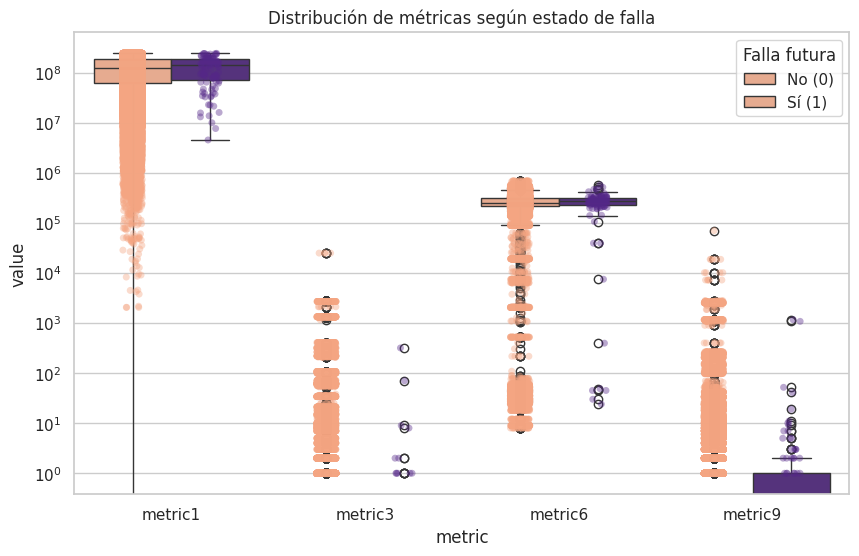

In [150]:
#|------------------------------|
#| Analisis y gráficos         -|
#|------------------------------|

# BoxPlot es un dragrama util para poder comparar entre distribuciones de datos
# En este caso buscamos comparar los datos distribuidos en cada dispositivo y sus estados de Falla y No Falla

sns.set(style="whitegrid")

palette = {
    0: "#f4a582",
    1: "#542788"
}

df_melt = df.melt(
    id_vars='failure',
    value_vars=['metric1','metric3','metric6','metric9'],
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(10,6))

sns.boxplot(
    x='metric',
    y='value',
    hue ='failure',
    data = df_melt,
    palette = palette,
)

sns.stripplot(
    x = 'metric',
    y = 'value',
    hue ='failure',
    data = df_melt,
    dodge = True,
    alpha = 0.4,
    palette = palette,
)

plt.yscale('log')
plt.title("Distribución de métricas según estado de falla")
plt.legend(title="Falla futura", labels=["No (0)", "Sí (1)"])
plt.show()

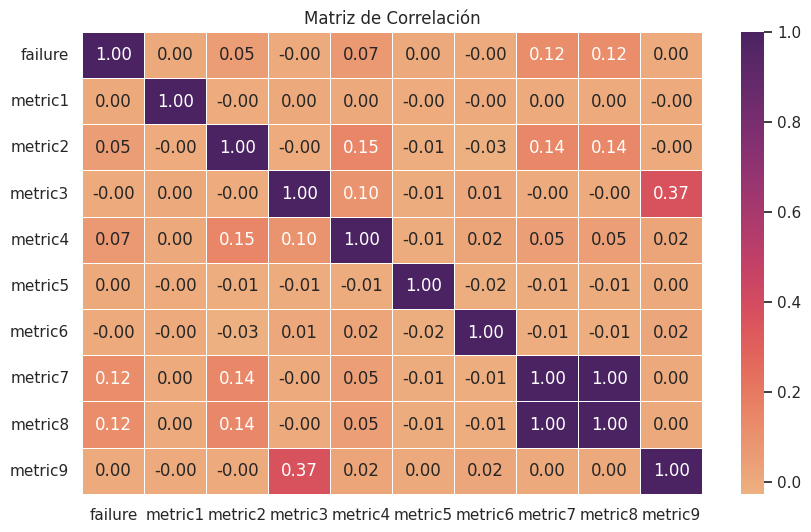

In [151]:
#|------------------------------|
#| Analisis y gráficos         -|
#|------------------------------|

# HeatMap es util para visualizar la relación entre las variables (metricas de cada dispositivo)

plt.figure( figsize = (10, 6))
sns.heatmap(
    df.corr(numeric_only = True),
    cmap = sns.color_palette("flare", as_cmap = True),
    annot = True,
    fmt = ".2f",
    linewidths = 0.5
)

plt.title ("Matriz de Correlación")
plt.show()


#### **Resumen**
#####_Hipotesis I_

> A traves de los diagramas de cajas y mapas de calor se busca comparar el comportamiento de los equipos en los estados de falla y no falla.

En los resultados se puede observar la presencia de fallas, pero la superposición de ambos estados no permite identificar de forma determinante la ocurrencia de fallas.

Es nos sugiere que el comportamiento de los equipos depende de la combinación de múltiples variables, necesitando aplicar modelos de ML para detectar patrones más complejos.

### **Hipotesis II**
####_El comportamiento indica cuando fallará_

> El comportamiento de las métricas permite anticipar la ocurrencia de las fallas.

Con las métricas opertivas se busca analizar patrones que se presentan previos a las falla a partir del comportamiento histórico de los sensores.


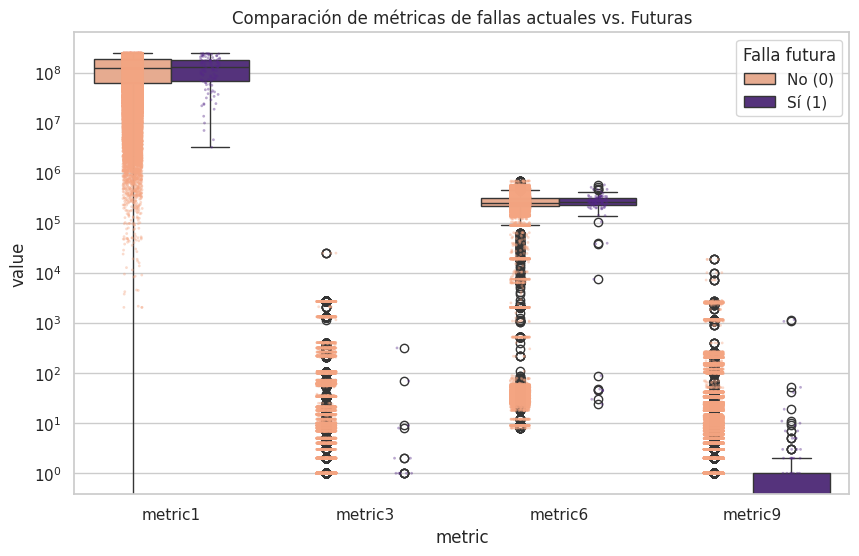

In [152]:
#|------------------------------|
#| Analisis y gráficos         -|
#|------------------------------|

# Como en el primer grafico, este diagrama nos permite evaluar la distribucion de datos entre periodos de tiempo, no solo en estados de Falla y No Falla

# Primero plantee una variable bandera que nos plantee los valores estandar del registro

df = df.sort_values(by = ['device', 'date'])


# Luego una variable que almacene el resultado despues del analisis y asi comparar

df['failure_next'] = df.groupby('device')['failure'].shift(-1)

# Al detectar el registro de falla futura, se desplazan los valores, es necesario limpiarlos

df = df.dropna()

# Comparación

sns.set(style="whitegrid")

palette = {
    0: "#f4a582",
    1: "#542788"
}

df_melt = df.melt(
    id_vars='failure_next',
    value_vars=['metric1','metric3','metric6','metric9'],
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(10,6))

sns.boxplot(
    x='metric',
    y='value',
    hue='failure_next',
    data=df_melt,
    palette = palette,
)

sns.stripplot(
    x = 'metric',
    y = 'value',
    hue = 'failure_next',
    data=  df_melt,
    dodge = True,
    alpha = 0.4,
    size = 2,
    palette = palette,
)

plt.yscale('log') # Las escalas se veian desproporcionadas evitando que se pudieran comparar a simple vista, esta funcion nos normaliza la escala
plt.title("Comparación de métricas de fallas actuales vs. Futuras")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], ["No (0)", "Sí (1)"], title="Falla futura")

plt.show()

#### **Resumen**
#####_Hipotesis II_

> Generando una variable que desplaza los valores obtenidos, nos permite predecir eventos futuros en relacion de las condiciones actuales.

Se puede observar en la distribución de algunas métricas antes de las fallas, esto nos sugiere el comportamiento anticipado de los equipos. Aun asi estas diferencias no son completamente separables, necesitando más variables que nos puedan indicar una predicción más fiel.


### **Hipotesis III**
####_Patron temporal de las fallas_

> Las fallas presentan patrones en el tiempo y no ocurren de forma completamente aleatoria.

En esta linea se busca analizar la distribución temporal de las fallas intentando identificar patrones, tendencias o concentraciones en el tiempo

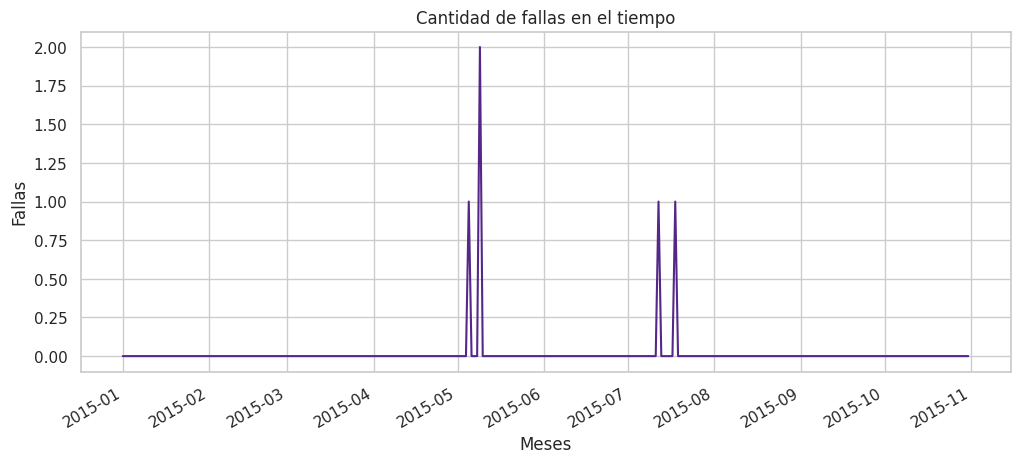

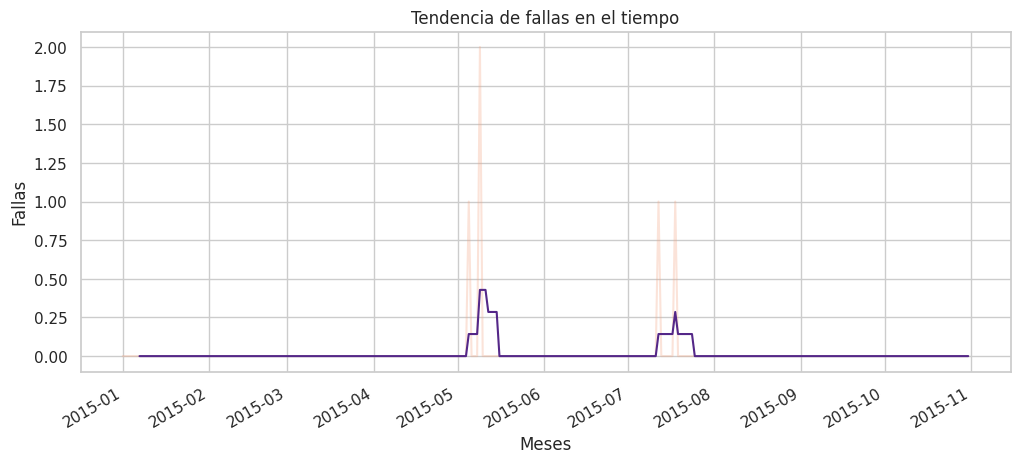

In [153]:
#|------------------------------|
#| Analisis y gráficos         -|
#|------------------------------|

# Teniendo datos de tiempo, es posible generar diagramas de lineas que nos idiquen tendencias y evoluciones temporales
# Los diagramas de lineas son ideales para este tipo de comparaciones

# Diseño

color_base = "#542788"
color_sec = "#f4a582"

# Segmentamos las variable de tiempo para tener un mejor dominio de los datos

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df_time = df.groupby('date')['failure'].sum()

df_time.plot(color = color_base, figsize = (12, 5))
plt.title("Cantidad de fallas en el tiempo")
plt.xlabel("Meses")
plt.ylabel("Fallas")

df_time = df.groupby('date')['failure'].sum()

plt.figure(figsize=(12,5))

# Como se muestra en el primer grafico, las variaciones son muy contrastantes, la funcion de media movil o rolling mean nos permite "suavizar" fluctuacioens
# En este caso calculamos la media aritmetica de los ultimos 7 dias.

df_time.plot(color = colorSec, alpha=0.3, label='Original')
df_time.rolling(7).mean().plot(color = color_base, label='Promedio móvil (7 días)')

plt.title("Tendencia de fallas en el tiempo")
plt.xlabel("Meses")
plt.ylabel("Fallas")
plt.show()

plt.show()

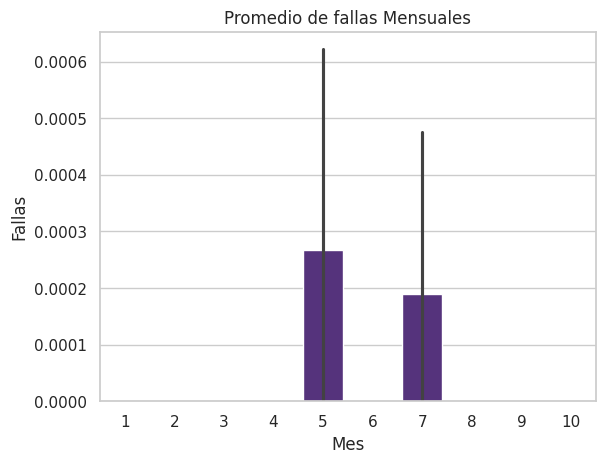

In [154]:
#|------------------------------|
#| Analisis y gráficos         -|
#|------------------------------|

# Con los datos temporales tambien podemos agruparlos por temporadas
# Los graficos de barra permiten identificar mejor los periodos y comprar, en este caso, promedio de fallas

palette = [color_sec if m % 2 == 0 else color_base for m in sorted(df['month'].unique())]

sns.barplot(
    x = 'month',
    y = 'failure',
    hue = 'month',
    data = df,
    palette = palette,
    legend = False
)

plt.title("Promedio de fallas Mensuales")
plt.xlabel("Mes")
plt.ylabel("Fallas")
plt.show()

#### **Resumen**
#####_Hipotesis III_

> El analisis temporal de las fallas no demuestra un comportamiento completamente aleatorio, pudiendo observar variaciones en la frecuencia de las fallas a lo largo del timepo

Podriamos sugerir que existe un patron temporal en el comportamiento de los equipos, pudiendo entontes hacer predicciones si se agregaran variables temporales en los modelos...

### *Hipotesis IV*
####_Que fallará_

> Existen equipos que muestran mayor porpensión a fallar que otros.

Con toda la información obtenida hasta ahora queremos detectar cuales son aquellos equipos problemáticos y cuales son más confiables.
Analizar la frecuencia de las fallas por equipo nos ayudará a identificar la propensión de las fallas.

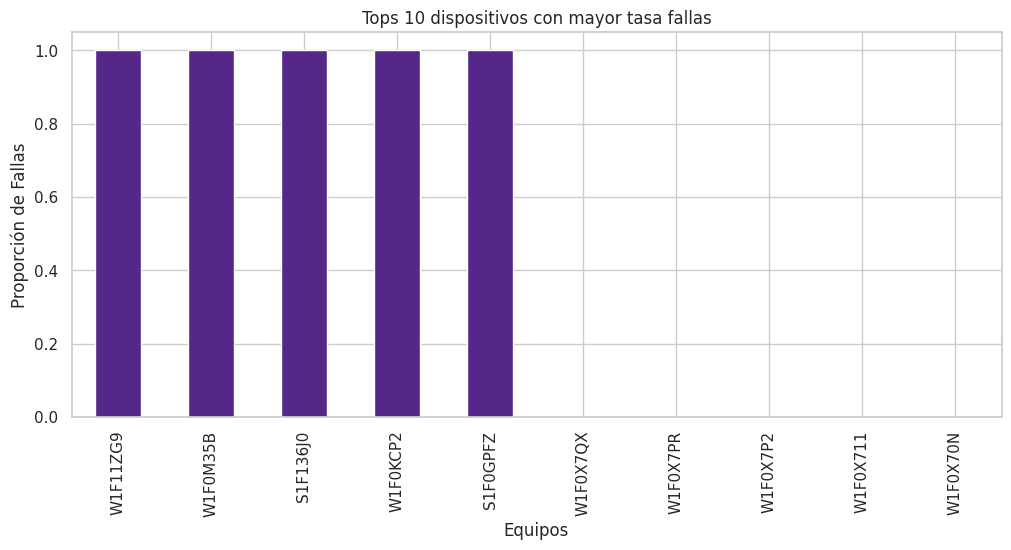

In [155]:
#|------------------------------|
#| Analisis y gráficos         -|
#|------------------------------|

# Para calcular la tasa de fallas se agruparon los equipos y se calculo el total de fallas de cada uno, luedo se ordeno de mayor a menos
# Esto nos permite comprar cada dispositivo y detectar cual tuvo una mayor frecuencia de falla absoluta

df_device_rate = df.groupby('device')['failure'].sum().sort_values(ascending = False)

plt.figure(figsize = (12, 5))
df_device_rate.head(10).plot(kind = 'bar', color = color_base)
plt.title ("Tops 10 dispositivos con más fallas")
plt.xlabel("Equipos")
plt.ylabel("Proporción de Fallas")
plt.show()

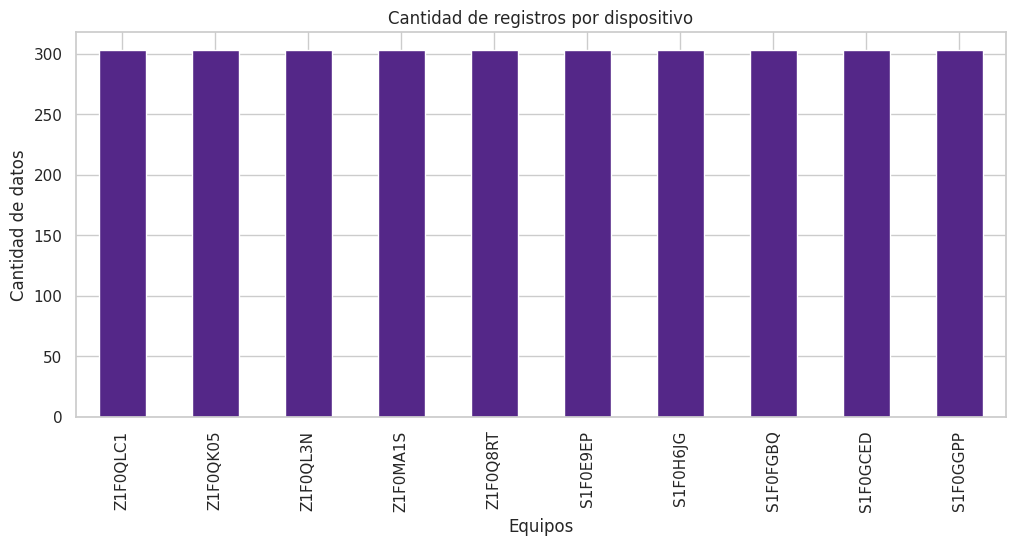

In [156]:
#|------------------------------|
#| Analisis y gráficos         -|
#|------------------------------|

# En este analisis se conto la cantidad de registro por equipo, evualuando asi la frecuencia opertaiva de cada uno
# Esto nos brinda un contexto para los fallos de cada uno, dandonos una proporcionalidad de los fallos segun el uso

df_device_count = df['device'].value_counts()

plt.figure(figsize = (12, 5))
df_device_count.head(10).plot(kind = 'bar', color = color_base)

plt.title("Cantidad de registros por dispositivo")
plt.xlabel("Equipos")
plt.ylabel("Cantidad de datos")

plt.show()

#### **Resumen**
#####_Hipotesis IV_

> Este analisis nos permite observar diferencias entre la frecuencia de fallas entre los equipos, oudiendo identificar equipos con mayor cantidad y proporción de fallos.

De igual manera es prudente considerar que tambien pueden verse expuestos a mayor cantidad de fallas debido a una mayor exposición de desgaste operativo.
Por eso debemos resaltar la importancia de analizar valores absolutos y relaticos para tener una correcta interpretación de las métricas.

### **Hipotesis V**
####_Impacto Acumulativo_

> El riesgo de falla aumenta en funcion del uso o el tiempo.

Para finalizar, se busca determinar si la probabilidad de falla de los equipos incrementa por el aumento de registros o por el uso de cada uno de ellos.

/tmp/ipykernel_1390/3456138857.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


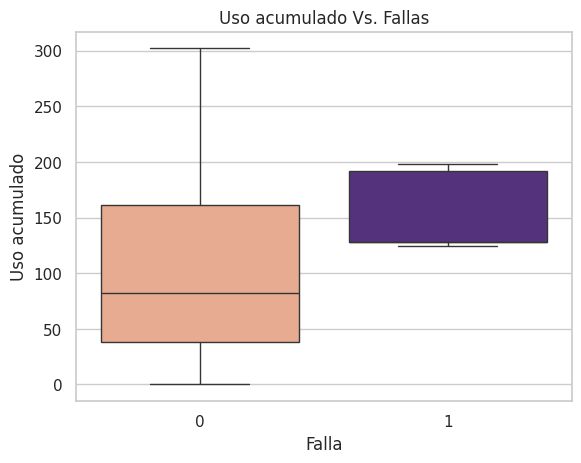

In [159]:
#|------------------------------|
#| Analisis y gráficos         -|
#|------------------------------|

# Primero designamos una variable bandera para contabilizar el uso de cada dispositivo

df['uso_acumulado'] = df.groupby('device').cumcount()

# Ahora pasamos a comparar las fallas en relación al uso de cada equipo

sns.boxplot(
    x = 'failure',
    y = 'uso_acumulado',
    data = df,
    palette=[color_sec, color_base],
    legend = False
)

plt.title("Uso acumulado Vs. Fallas")
plt.xlabel("Falla")
plt.ylabel("Uso acumulado")
plt.show()



#### **Resumen**
#####_Hipotesis V_

> Se observa una tendencia donde los eventos de falla tienden a ocurrir con mayor frecuencia cuanto mayor es el uso acumulado, lo que nos sugiere un efecto de falla debido al desgaste operativo.

Considerando este resultado, es escencial tener un registro fiel del uso de cada equipo para poder planificar los mantenimientos preventivos. Esto podria complementarse con información sobre la productividad de cada equipo, rendimiento y objetivos de producción.

### **Conclusión**
#####_Resultado sobre las métricas operativas_

> A traves de los distintos analisis fue posible identificar que el comportamiento de los equipos no responde a una unica variable, sino que intervienen multiples metricas operativas.

Aunque se destacan las diferencias entre los estados de Falla y No Falla, estanos no permiten explicar completamente los eventos de fallo.

Si bien el analisis temporal nos permitio visualizar comportamientos irregulares estos no representan una estacionaldiad clara. Cuando se analizan los datos proporcionados por los equipos permitio identificar mejor la frecuencia de los estados de falla, considerando resutados absolutos y relativos.



### **Maching Learning**
#### _Estudio de los registros_

> Dado que el análisis exploratorio no permite identificar reclas claras de desición, se busca implementar un modelo de Machine Learning para identificar patrones más complejos.

In [168]:
#|-------------------------------|
#| Evaluación de Registros      -|
#|-------------------------------|

# Definición de Variables

x = df.drop(columns = ['failure', 'failure_next', 'date', 'device'])
y = df['failure_next']

# Librerias

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Testeo

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

# Modelo Random Forest

model = RandomForestClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# Evaluación

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     24644
         1.0       0.00      0.00      0.00        21

    accuracy                           1.00     24665
   macro avg       0.50      0.50      0.50     24665
weighted avg       1.00      1.00      1.00     24665



### **Conclusión Final**
#### _Modelo de predicción_

> Este modelo de ML recibe como entrada las métricas operativas actuales y genera una predicción binaria indicando si el equipo presentara fallas en el siguiente periodo.

Es decir, este modelo nos esta permitiendo anticipar eventos de fallo a partir del comportamiento histórico de los sensores.

#### _Análisis Univariado_

> Al inicio analizamos la descripción de los registros de los equipos, donde buscamos comprender su distribución, dispersión y valores atípicos, utilizando estadísticas descriptivas y visualizaciones como boxplot.

#### _Análisis Bivariado_

> A través del análisis comparativo entre las métricas opertaivas y las fallas registradas, pudimos diagramar una relacion bivariada, pudiendo identificar asociaciones y patrones relevantes para la contrucción del modelo predictivo.

_Cierre_

Dado que el registro muestra un gran desbalance de estados de Falla y No Falla, la utilidad de la deteccion de eventos se limita.

Solo a modo de prueba, vamos a darle al modelo la instruccion de detectar las Fallas y contextualizarlas para determinar si existen valores determinantes para este estado.

In [172]:
# Testeo

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

# Modelo Random Forest

model = RandomForestClassifier(class_weight = 'balanced')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# Evaluación

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     24646
         1.0       0.00      0.00      0.00        19

    accuracy                           1.00     24665
   macro avg       0.50      0.50      0.50     24665
weighted avg       1.00      1.00      1.00     24665



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


_Final_

> La baja frecuencia de estados de Falla representa el comportamiento tipico de contextos industriales; el estado de falla es poco comun, pero critico, generando un desbalance de datos y dificultando su predicción.

1. ¿Qué variables influyen más en una falla?

> No se identificó una única variable determinante.
Las fallas dependen de la combinación de múltiples métricas operativas, lo que evidencia un comportamiento complejo y no lineal.

2. ¿Podemos predecir si un equipo va a fallar?

> Sí, es posible construir modelos predictivos capaces de anticipar fallas.
Sin embargo, su efectividad depende de la calidad y balance de los datos disponibles.

3. ¿Qué tan preciso es el modelo?

> El modelo presenta alta precisión en la detección de estados normales, pero baja capacidad para identificar fallas debido al desbalance del dataset.
Esto refleja una limitación común en problemas reales de mantenimiento predictivo.


#### 👩‍💻 Autor

- **Nombre:** Silvina Danisa Moreno  
- **Mail:** silvina.danisa.moreno@gmail.com  
- **GitHub:** SilvinaMoreno
- **Comisión:** 77790  
- **Año:** 2026  